In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, precision_recall_curve,precision_score, recall_score

from xgboost import XGBClassifier

In [189]:
df=pd.read_csv("Loan_default.csv")

In [190]:
print(df.shape)

(255347, 18)


In [191]:
print(df.head())

       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      Divorced         Yes           Yes       Other   
1      Full-time    

In [192]:
print(df.info(memory_usage='deep'))

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

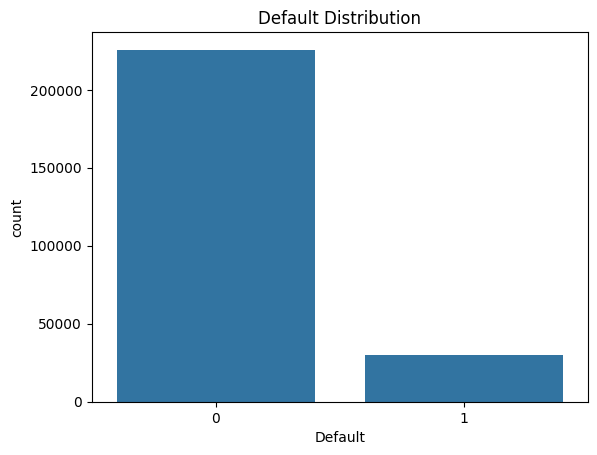

In [193]:
#Target Distribution Graph:- good for target visualization
sns.countplot(x='Default',data=df)
plt.title("Default Distribution")
plt.show()

In [194]:
# Missing Values
print(df.isnull().sum().sort_values(ascending=False).head(10))

LoanID            0
Age               0
HasCoSigner       0
LoanPurpose       0
HasDependents     0
HasMortgage       0
MaritalStatus     0
EmploymentType    0
Education         0
DTIRatio          0
dtype: int64


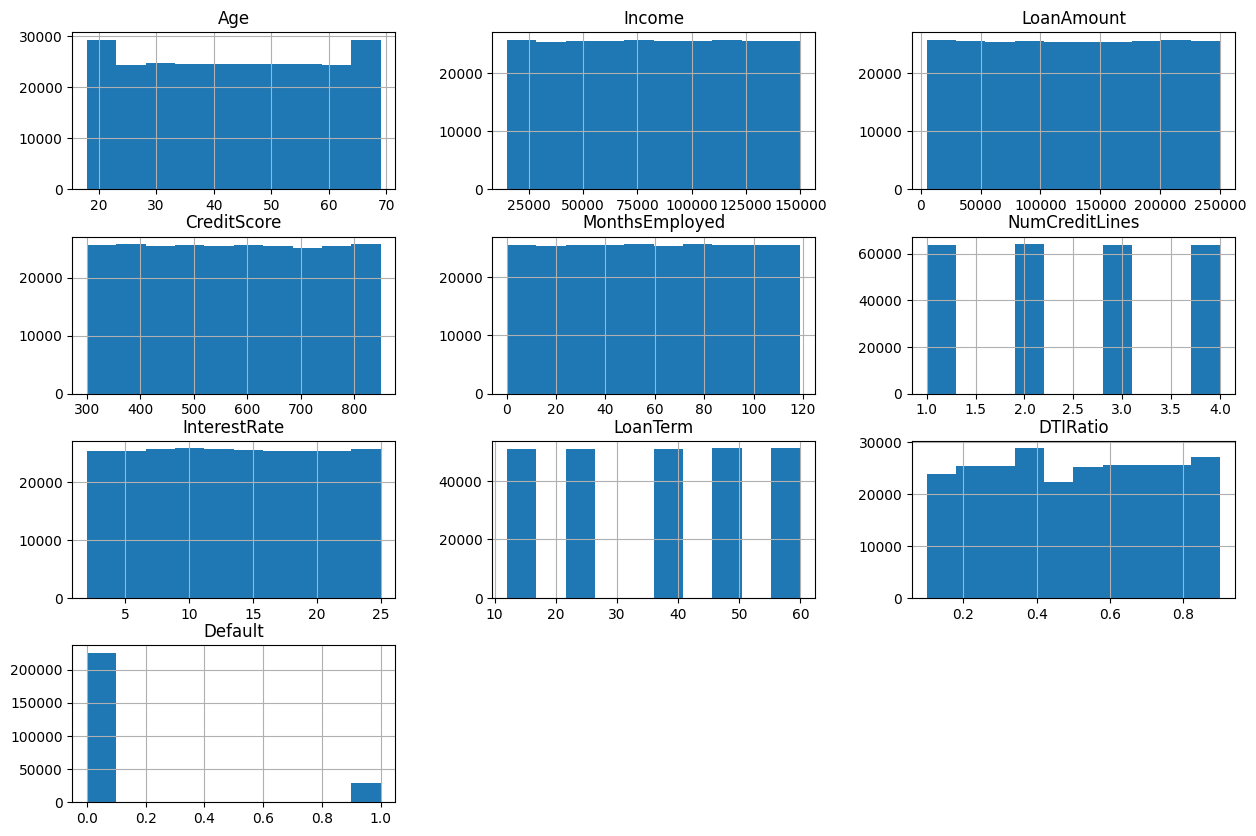

In [195]:
df.hist(figsize=(15,10))
plt.show()

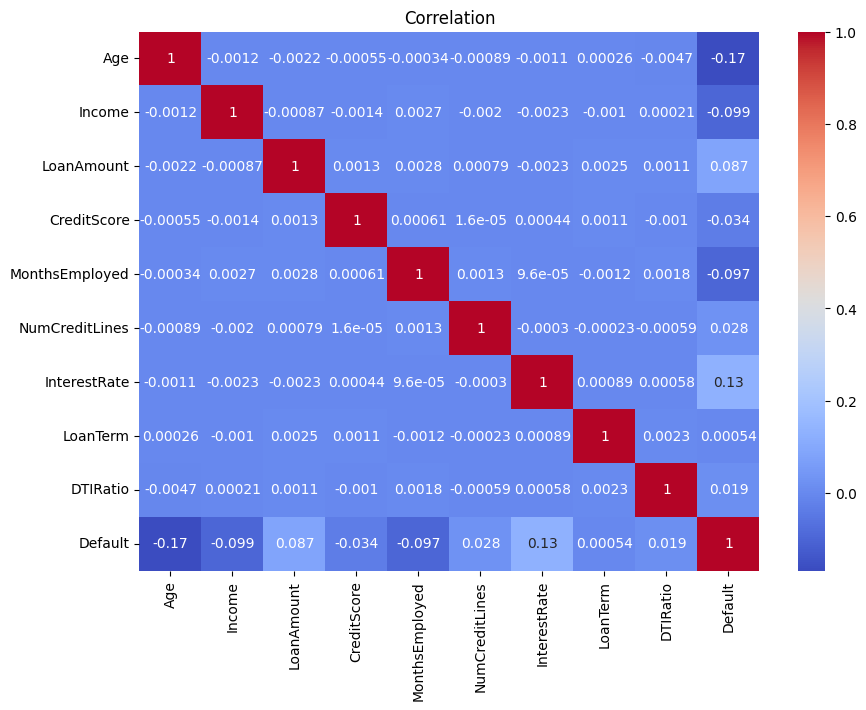

In [196]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation")
plt.show()

In [197]:
#Drop useless columns (if present)
drop_cols=['LoanID']

In [198]:
df['loan_income_ratio']=df['LoanAmount']/(df['Income']+1)
df['credit_per_duration']=df['LoanAmount']/(df['LoanTerm']+1)
df['loan_per_term']=df['LoanAmount']/(df['LoanTerm']+1)

In [199]:
df=df.drop(columns=[col for col in drop_cols if col in df.columns])

In [200]:
#Target
X=df.drop('Default',axis=1)
y=df['Default']

In [201]:
# Column types
num_cols=X.select_dtypes(include=['int64','float64']).columns
cat_cols=X.select_dtypes(include=['object']).columns

print("Numerical:",num_cols)
print("Categorical:",cat_cols)

Numerical: Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
       'loan_income_ratio', 'credit_per_duration', 'loan_per_term'],
      dtype='str')
Categorical: Index(['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
       'HasDependents', 'LoanPurpose', 'HasCoSigner'],
      dtype='str')


/var/folders/qm/9sp84qp90fv_1l7ftx_hr4r80000gn/T/ipykernel_68869/91225328.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=X.select_dtypes(include=['object']).columns


In [202]:
# PIPELINE
num_pipeline=Pipeline([
    ('scaler',StandardScaler())])
cat_pipeline=Pipeline([
    ('encoder',OneHotEncoder(handle_unknown='ignore'))])
preprocessor=ColumnTransformer([
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)])

In [203]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [204]:
neg=np.sum(y_train==0)
pos=np.sum(y_train==1)
balanced_value=neg/pos
print("scale_pos_weight:",balanced_value)

scale_pos_weight: 7.61128909872692


In [205]:
model=Pipeline([
    ('preprocessing',preprocessor),
    ('classifier',XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42))])

In [206]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [252]:
y_prob=model.predict_proba(X_test)[:,1]
y_pred=(y_prob>0.3).astype(int)

In [253]:
y_pred=model.predict(X_test)

In [254]:
print("Precission: ",precision_score(y_test,y_pred))
print("Recall: ",recall_score(y_test,y_pred))

Precission:  0.6114754098360655
Recall:  0.06288990052267746


In [255]:
#Report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.61      0.06      0.11      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.53      0.53     51070
weighted avg       0.86      0.89      0.84     51070



In [256]:
precision,recall,thresholds=precision_recall_curve(y_test,y_prob)
print("Precision: ",precision[:5])
print("Recall: ",recall[:5])
print("Thresholds:",thresholds[:5])

Precision:  [0.11613472 0.11613699 0.11613927 0.11614154 0.11614381]
Recall:  [1. 1. 1. 1. 1.]
Thresholds: [0.00370124 0.00486245 0.00502416 0.0051718  0.00517232]


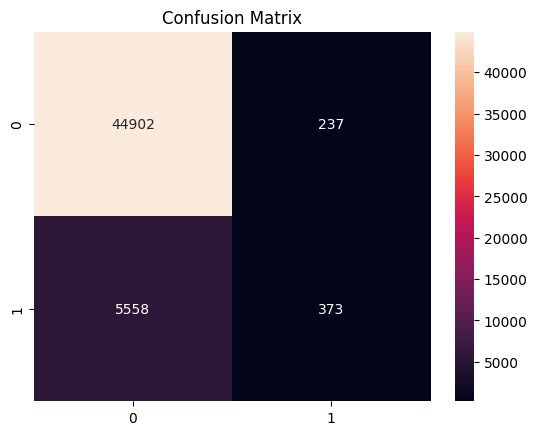

In [257]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [230]:
roc_score=roc_auc_score(y_test, y_prob)
print("ROC-AUC: ",roc_score)

ROC-AUC:  0.7590919752852137


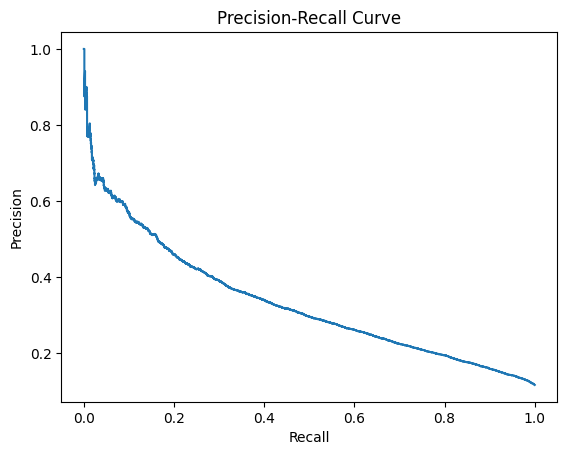

In [233]:
plt.plot(recall,precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [223]:
precision,recall,thresholds=precision_recall_curve(y_test,y_prob)
f1_scores=2*(precision*recall)/(precision+recall)
best_idx=np.argmax(f1_scores)
best_thresholds=thresholds[best_idx]
print("Best Threshold: ",best_thresholds)
print("Precision: ",precision[best_idx])
print("Recall: ",recall[best_idx])
print("F1 score: ",f1_scores[best_idx])

Best Threshold:  0.18895483
Precision:  0.3102681054622316
Recall:  0.47024110605294217
F1 score:  0.37386058981233244


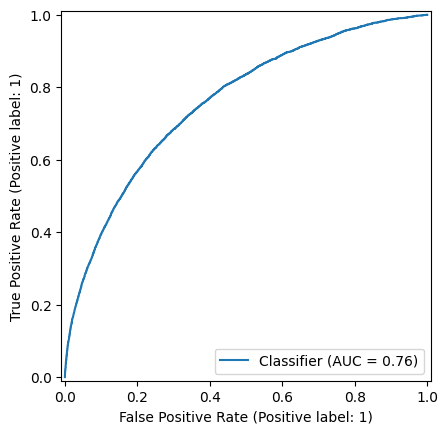

In [224]:
RocCurveDisplay.from_predictions(y_test,y_prob)
plt.show()

In [105]:
def recommend(row,pred):
    if pred==1:
        suggestions=[]
        if 'LonaAmount' in row and row['LoanAmount']>500000:
            suggestions.append("Reduce loan amount")
        if 'Income' in row and row['Income']<30000:
            suggestions.append("Verify income/request proof")
        if 'CreditScore' in row and row['CreditScore']<600:
            suggestions.append("Improve credit score or add guarantor")
        if len(suggestions)==0:
            suggestions.append("Require manual review")
        return suggestions
    else:
        return ["Approve loan"]

In [106]:
sample=X_test.iloc[[0]]
pred=model.predict(sample)[0]
print("Prediction: ",pred)
print("Recommendation: ",recommend(sample.iloc[0],pred))

Prediction:  0
Recommendation:  ['Approve loan']
